# 🔍 Exploratory Data Analysis (EDA) — Детекция ботов для сбора данных

**Задача:** Классификация сессий пользователей (`cookie_id`) на положительный класс (боты/парсеры: `target = 1`) и отрицательный класс (люди: `target = 0`).  
**Метрика кейса:** Precision @ Recall $\ge$ 0.70 (официальная реализация из `metric.py`).

---

### План исследовательского анализа:
1. **Базовая проверка структуры выборок и временных окон:**
   - Размеры `train`, `test`, `events`, баланс классов и уровень константы.
   - Пересечение `cookie_id` и проверка покрытия событиями.
   - Анализ длительности окон наблюдения и Out-of-Time сплит (`train` vs `test`).
   - ⚠️ **Критический капкан данных:** события за пределами окна наблюдения и утечка капчи.
   - Возраст куки (`cookie_created_at` vs `window_start_ts`).
2. **Анализ лога событий (`events.csv.gz`):**
   - Распределение `eid` и `event_name`, расчет Univariate Lift по типам событий.
   - Анализ пропусков: поведение курсора мыши (`pointer_x`/`pointer_y`) на десктопе vs мобильных.
3. **Анализ платформ и User-Agent:**
   - Нормализация регистра платформ.
   - Разбор User-Agent: явные скраперы vs спуфинг обычных браузеров. Почему UA нельзя брать «в лоб».
4. **Временная динамика событий и циркадные ритмы:**
   - Проверка порядка строк и дубликатов в логах.
   - Межсобытийные интервалы $\Delta t$ (моменты времени вместо простых счетчиков).
   - Распределение активности по 24 часам суток (ночной скрапинг vs пики живых людей).
5. **Поведение в каталоге, глубина поиска и со-визитация:**
   - Специализация по категориям vs географический охват локаций.
   - Глубина пагинации поисковой выдачи (`search_page`).
   - Со-визитация объявлений: совместный интерес кук к объектам каталога.
6. **Сводные выводы и план Feature Engineering:**
   - Ответы на вопросы авторов кейса.
   - Приоритетный список признаков для валидации и бустинга.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка визуального оформления
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (11, 5)

train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('data/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])

print(f"Train:  {train.shape[0]:>6} строк, {train.shape[1]} колонок")
print(f"Test:   {test.shape[0]:>6} строк, {test.shape[1]} колонок")
print(f"Events: {events.shape[0]:>6} строк, {events.shape[1]} колонок")


Train:   11091 строк, 5 колонок
Test:     4909 строк, 4 колонок
Events: 328905 строк, 14 колонок


## 1. Базовая проверка структуры выборки и временных окон

### 1.1 Размеры выборок и баланс классов
В задаче классификации ботов критически важно знать базовую частоту положительного класса. В условиях сильного дисбаланса метрика Precision @ Recall $\ge$ 0.70 на константном/случайном предсказании будет равна доле ботов.


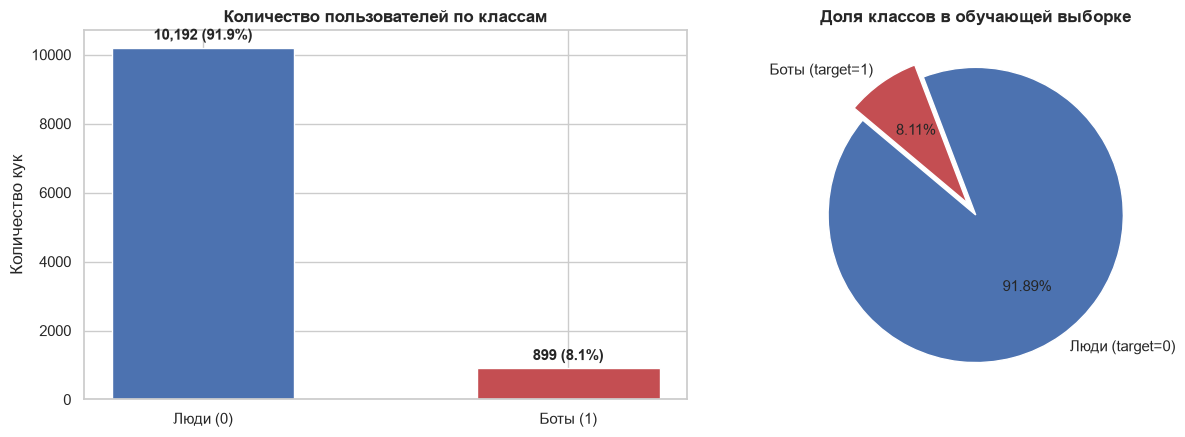

Всего кук в train: 11091
Люди (target=0):   10192 (91.8943%)
Боты (target=1):   899 (8.1057%)
Уровень константы для Precision: 0.0811


In [2]:
target_counts = train['target'].value_counts()
target_props = train['target'].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Столбчатая диаграмма
bars = axes[0].bar(['Люди (0)', 'Боты (1)'], target_counts.values, color=['#4C72B0', '#C44E52'], width=0.5)
axes[0].set_title('Количество пользователей по классам', fontweight='bold')
axes[0].set_ylabel('Количество кук')
for bar in bars:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval + 150, f'{yval:,} ({yval/len(train):.1%})', ha='center', va='bottom', fontweight='bold')

# Круговая диаграмма
axes[1].pie(target_counts.values, labels=['Люди (target=0)', 'Боты (target=1)'], 
            autopct='%1.2f%%', startangle=140, colors=['#4C72B0', '#C44E52'], explode=(0, 0.1))
axes[1].set_title('Доля классов в обучающей выборке', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Всего кук в train: {len(train)}")
print(f"Люди (target=0):   {target_counts[0]} ({target_props[0]:.4%})")
print(f"Боты (target=1):   {target_counts[1]} ({target_props[1]:.4%})")
print(f"Уровень константы для Precision: {target_props[1]:.4f}")


### 1.2 Пересечение кук между train/test и покрытие событиями
Проверим:
1. Пересекаются ли `cookie_id` между `train` и `test`?
2. Есть ли в `train` или `test` куки, для которых нет ни одного события в `events.csv.gz`?


In [3]:
train_cookies = set(train.cookie_id)
test_cookies = set(test.cookie_id)
event_cookies = set(events.cookie_id)

overlap = train_cookies & test_cookies
train_in_events = len(train_cookies & event_cookies)
test_in_events = len(test_cookies & event_cookies)

print(f"Пересечение cookie_id между train и test: {len(overlap)}")
print(f"Куки из train, найденные в events: {train_in_events} из {len(train)} ({train_in_events/len(train):.1%})")
print(f"Куки из test, найденные в events:  {test_in_events} из {len(test)} ({test_in_events/len(test):.1%})")
assert len(overlap) == 0, "Обнаружена утечка: одни и те же куки есть и в train, и в test!"
assert train_in_events == len(train), "Есть куки train без событий!"
assert test_in_events == len(test), "Есть куки test без событий!"


Пересечение cookie_id между train и test: 0
Куки из train, найденные в events: 11091 из 11091 (100.0%)
Куки из test, найденные в events:  4909 из 4909 (100.0%)


### 1.3 Временные окна наблюдения: длительность и Out-Of-Time (OOT) сплит

Проверим длительность окон наблюдения `window_end_ts - window_start_ts` и календарный период сбора данных для `train` и `test`.


Длительность окон в train: {Timedelta('1 days 00:00:00'): 11091}
Длительность окон в test:  {Timedelta('1 days 00:00:00'): 4909}


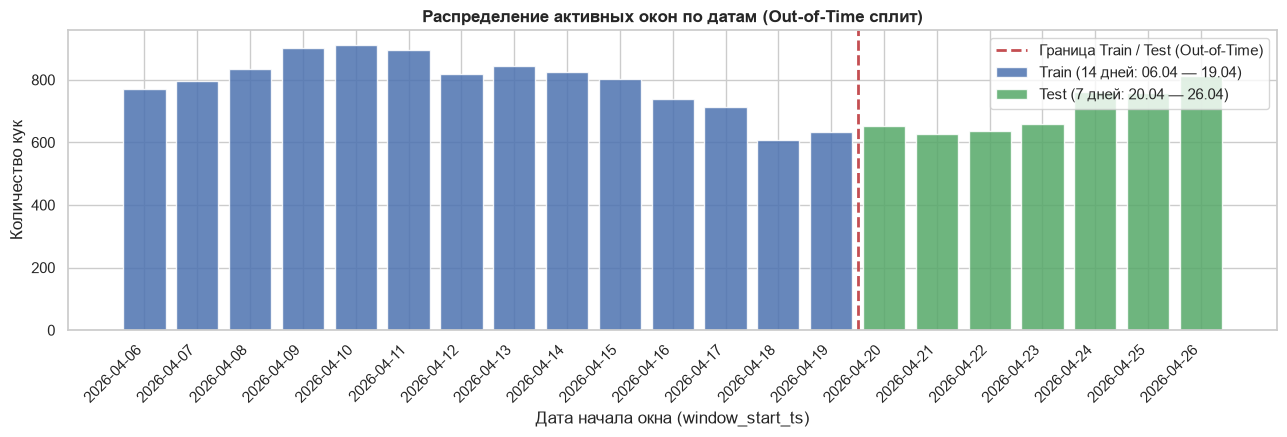

Период Train: 2026-04-06 — 2026-04-19 (14 дней)
Период Test:  2026-04-20 — 2026-04-26 (7 дней)


In [4]:
train['window_duration'] = train.window_end_ts - train.window_start_ts
test['window_duration'] = test.window_end_ts - test.window_start_ts

print("Длительность окон в train:", train['window_duration'].value_counts().to_dict())
print("Длительность окон в test: ", test['window_duration'].value_counts().to_dict())

train_days = train.window_start_ts.dt.date.value_counts().sort_index()
test_days = test.window_start_ts.dt.date.value_counts().sort_index()

plt.figure(figsize=(13, 4.5))
plt.bar(train_days.index.astype(str), train_days.values, color='#4C72B0', label='Train (14 дней: 06.04 — 19.04)', alpha=0.85)
plt.bar(test_days.index.astype(str), test_days.values, color='#55A868', label='Test (7 дней: 20.04 — 26.04)', alpha=0.85)
plt.axvline(x=13.5, color='#C44E52', linestyle='--', linewidth=2, label='Граница Train / Test (Out-of-Time)')
plt.xticks(rotation=45, ha='right')
plt.title('Распределение активных окон по датам (Out-of-Time сплит)', fontweight='bold')
plt.xlabel('Дата начала окна (window_start_ts)')
plt.ylabel('Количество кук')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

print(f"Период Train: {train.window_start_ts.min().date()} — {train.window_start_ts.max().date()} ({train.window_start_ts.nunique()} дней)")
print(f"Период Test:  {test.window_start_ts.min().date()} — {test.window_start_ts.max().date()} ({test.window_start_ts.nunique()} дней)")


### 1.4 ⚠️ КРИТИЧЕСКИЙ КАПКАН ДАННЫХ: События за пределами окна и утечка капчи!

В условии задачи строго сказано:
> *«Признаки должны быть доступны на момент окончания окна наблюдения. Признаки считаем только по событиям внутри окна: `window_start_ts <= event_ts < window_end_ts`»*.

Проверим, есть ли в `events.csv.gz` события за пределами заданного суточного окна для обучающей и тестовой выборок.


In [5]:
ev_tr = events.merge(train[['cookie_id', 'window_start_ts', 'window_end_ts', 'target']], on='cookie_id')
ev_te = events.merge(test[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')

tr_before = (ev_tr.event_ts < ev_tr.window_start_ts).sum()
tr_in = ((ev_tr.event_ts >= ev_tr.window_start_ts) & (ev_tr.event_ts < ev_tr.window_end_ts)).sum()
tr_after = (ev_tr.event_ts >= ev_tr.window_end_ts).sum()

te_before = (ev_te.event_ts < ev_te.window_start_ts).sum()
te_in = ((ev_te.event_ts >= ev_te.window_start_ts) & (ev_te.event_ts < ev_te.window_end_ts)).sum()
te_after = (ev_te.event_ts >= ev_te.window_end_ts).sum()

df_window_check = pd.DataFrame({
    'Train события': [tr_before, tr_in, tr_after, len(ev_tr)],
    'Test события': [te_before, te_in, te_after, len(ev_te)],
}, index=['До окна (event_ts < start)', 'Внутри окна (start <= ts < end)', 'После окна (event_ts >= end)', 'Всего событий'])
print(df_window_check)

# Проверяем загадочный тип события captcha_shown
captcha_all = events[events.event_name == 'captcha_shown']
captcha_train_after = ev_tr[(ev_tr.event_name == 'captcha_shown') & (ev_tr.event_ts >= ev_tr.window_end_ts)]
captcha_train_in = ev_tr[(ev_tr.event_name == 'captcha_shown') & (ev_tr.event_ts >= ev_tr.window_start_ts) & (ev_tr.event_ts < ev_tr.window_end_ts)]
captcha_test = ev_te[ev_te.event_name == 'captcha_shown']

print("\n" + "="*70)
print(f"Всего показов капчи (captcha_shown) в файле events: {len(captcha_all)}")
print(f"Показов капчи ВНУТРИ окна в Train: {len(captcha_train_in)}")
print(f"Показов капчи ПОСЛЕ окна в Train:   {len(captcha_train_after)}")
print(f"Показов капчи в Test:               {len(captcha_test)}")
print("="*70)


                                 Train события  Test события
До окна (event_ts < start)                   0             0
Внутри окна (start <= ts < end)         198436         89690
После окна (event_ts >= end)             40779             0
Всего событий                           239215         89690

Всего показов капчи (captcha_shown) в файле events: 7928
Показов капчи ВНУТРИ окна в Train: 0
Показов капчи ПОСЛЕ окна в Train:   7928
Показов капчи в Test:               0


### 💡 Вывод по разделу 1.4:
1. **В обучающей выборке присутствуют 40 779 событий ПОСЛЕ окончания суточного окна!**
2. В тестовой выборке события после окна полностью отсутствуют (все 89 690 событий строго внутри окна).
3. **ВСЕ 7 928 событий показа капчи (`captcha_shown`) в `events.csv.gz` произошли ПОСЛЕ окна наблюдения в train!** Внутри окон и в тесте показов капчи ровно 0.
4. Если не выполнить строгую фильтрацию `window_start_ts <= event_ts < window_end_ts`, модель переобучится на события из будущего (особенно на факт срабатывания антибот-капчи), а на тесте этот признак будет тождественно нулевым. Это гарантированный провал на скрытом тесте.


### 1.5 Возраст куки (`cookie_created_at` vs `window_start_ts`)
Проверим гипотезу: скраперы чаще генерируют или сбрасывают куки, используя свежие «новореги», в то время как живые пользователи пользуются своими браузерами месяцами.


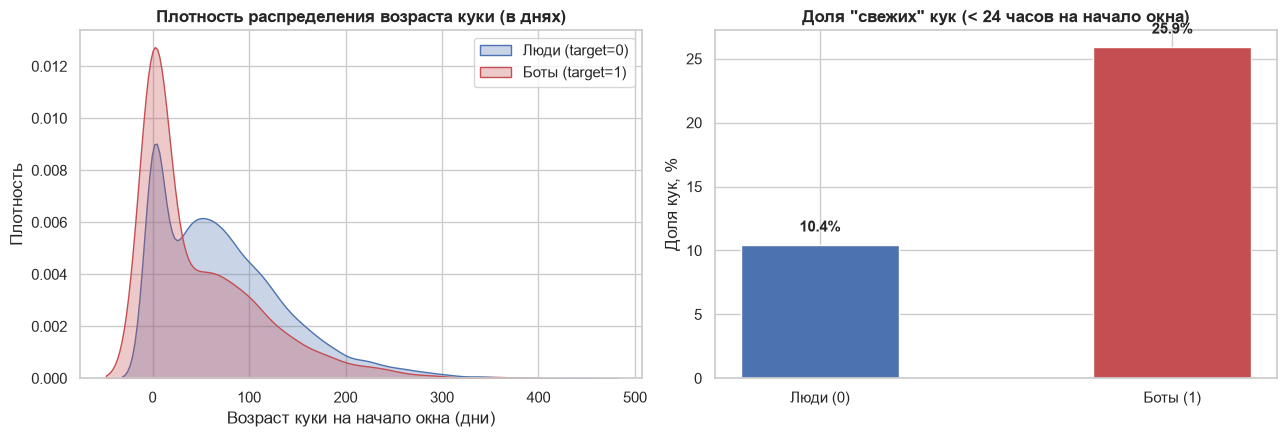

Статистика возраста куки (в днях):
        Люди (target=0)  Боты (target=1)
count          10192.00           899.00
median            61.78            18.97
mean              73.91            48.73
std               66.97            62.80


In [6]:
train['cookie_age_days'] = (train.window_start_ts - train.cookie_created_at).dt.total_seconds() / 86400.0
test['cookie_age_days'] = (test.window_start_ts - test.cookie_created_at).dt.total_seconds() / 86400.0

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Распределение возраста по классам (KDE)
sns.kdeplot(train[train.target == 0]['cookie_age_days'], ax=axes[0], label='Люди (target=0)', color='#4C72B0', fill=True, alpha=0.3)
sns.kdeplot(train[train.target == 1]['cookie_age_days'], ax=axes[0], label='Боты (target=1)', color='#C44E52', fill=True, alpha=0.3)
axes[0].set_title('Плотность распределения возраста куки (в днях)', fontweight='bold')
axes[0].set_xlabel('Возраст куки на начало окна (дни)')
axes[0].set_ylabel('Плотность')
axes[0].legend(frameon=True)

# Доля одноразовых/свежих кук (< 1 дня)
fresh_props = train.groupby('target')['cookie_age_days'].apply(lambda x: (x < 1.0).mean()) * 100
bars = axes[1].bar(['Люди (0)', 'Боты (1)'], fresh_props.values, color=['#4C72B0', '#C44E52'], width=0.45)
axes[1].set_title('Доля "свежих" кук (< 24 часов на начало окна)', fontweight='bold')
axes[1].set_ylabel('Доля кук, %')
for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

age_stats = train.groupby('target')['cookie_age_days'].agg(['count', 'median', 'mean', 'std']).T
age_stats.columns = ['Люди (target=0)', 'Боты (target=1)']
print("Статистика возраста куки (в днях):")
print(age_stats.round(2))


## 2. Анализ лога событий (`events.csv.gz`)

Отфильтруем события строго внутри окон наблюдения:
`window_start_ts <= event_ts < window_end_ts`


In [7]:
# Оставляем только валидные события строго внутри суточного окна
ev_tr_in = ev_tr[(ev_tr.event_ts >= ev_tr.window_start_ts) & (ev_tr.event_ts < ev_tr.window_end_ts)].copy()
ev_te_in = ev_te[(ev_te.event_ts >= ev_te.window_start_ts) & (ev_te.event_ts < ev_te.window_end_ts)].copy()

print(f"Событий внутри окна в Train: {len(ev_tr_in):,}")
print(f"Событий внутри окна в Test:  {len(ev_te_in):,}")
print(f"Кук в train с событиями внутри окна: {ev_tr_in.cookie_id.nunique()} из {len(train)}")
print(f"Кук в test с событиями внутри окна:  {ev_te_in.cookie_id.nunique()} из {len(test)}")


Событий внутри окна в Train: 198,436
Событий внутри окна в Test:  89,690
Кук в train с событиями внутри окна: 11091 из 11091
Кук в test с событиями внутри окна:  4909 из 4909


### 2.1 Распределение типов событий (`event_name`) и Univariate Lift
Изучим частоту каждого типа действия и рассчитаем **Univariate Lift**:
$$\text{Lift} = \frac{\text{Доля кук-ботов, совершивших событие}}{\text{Доля людей, совершивших событие}}$$
Это сразу покажет, какие действия отличают ботов от живых пользователей.


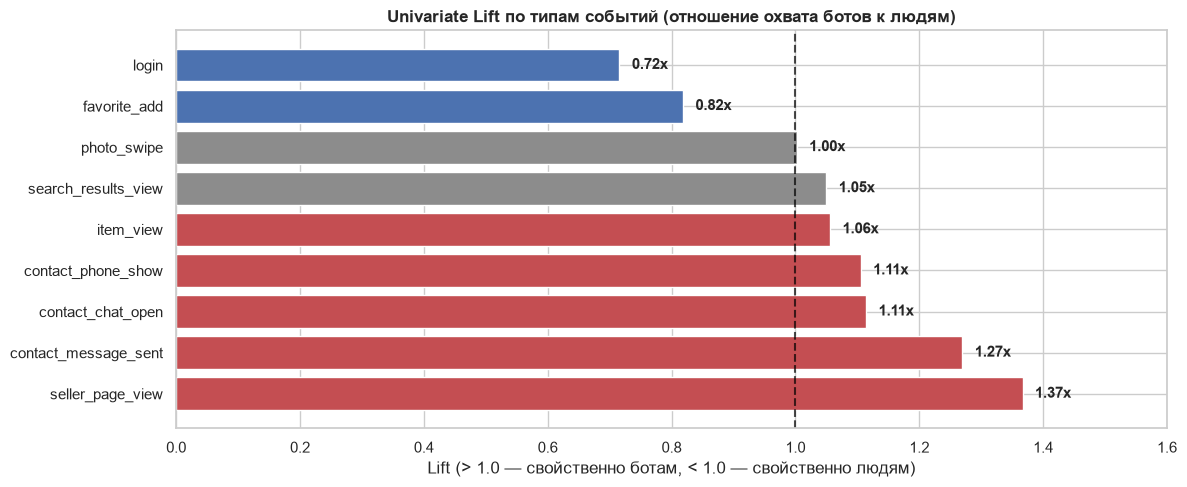

                      Охват людей (% кук)  Охват ботов (% кук)  \
event_name                                                       
seller_page_view                   49.480               67.631   
contact_message_sent               13.668               17.353   
contact_chat_open                  22.861               25.473   
contact_phone_show                 34.812               38.487   
item_view                          93.004               98.220   
search_results_view                91.327               95.884   
photo_swipe                        73.028               73.192   
favorite_add                       54.768               44.828   
login                              26.884               19.244   

                      Lift (Бот / Человек)  
event_name                                  
seller_page_view                     1.367  
contact_message_sent                 1.270  
contact_chat_open                    1.114  
contact_phone_show                   1.106  
ite

In [8]:
# Распределение самих событий
event_shares = pd.crosstab(ev_tr_in['event_name'], ev_tr_in['target'], normalize='columns')
event_shares.columns = ['Доля у людей', 'Доля у ботов']

# Доля пользователей (кук), совершивших хотя бы одно такое действие
cookie_event_counts = ev_tr_in.groupby(['cookie_id', 'target', 'event_name']).size().unstack(fill_value=0)

human_mask = cookie_event_counts.index.get_level_values('target') == 0
bot_mask = cookie_event_counts.index.get_level_values('target') == 1

reach_human = (cookie_event_counts[human_mask] > 0).mean()
reach_bot = (cookie_event_counts[bot_mask] > 0).mean()

lift_df = pd.DataFrame({
    'Охват людей (% кук)': reach_human * 100,
    'Охват ботов (% кук)': reach_bot * 100,
    'Lift (Бот / Человек)': reach_bot / reach_human
}).sort_values('Lift (Бот / Человек)', ascending=False)

plt.figure(figsize=(12, 5))
colors = ['#C44E52' if x > 1.05 else '#4C72B0' if x < 0.95 else '#8C8C8C' for x in lift_df['Lift (Бот / Человек)']]
bars = plt.barh(lift_df.index, lift_df['Lift (Бот / Человек)'], color=colors)
plt.axvline(x=1.0, color='black', linestyle='--', alpha=0.7)
plt.title('Univariate Lift по типам событий (отношение охвата ботов к людям)', fontweight='bold')
plt.xlabel('Lift (> 1.0 — свойственно ботам, < 1.0 — свойственно людям)')
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.02, bar.get_y() + bar.get_height()/2.0, f'{w:.2f}x', va='center', fontweight='bold')
plt.xlim(0, 1.6)
plt.tight_layout()
plt.show()

print(lift_df.round(3))


### 💡 Выводы по типам событий:
1. **`seller_page_view` (Lift 1.37x):** Боты значительно чаще переходят на профили продавцов (сбор контактов и каталогов продавца).
2. **`contact_message_sent` (Lift 1.27x):** Автоматизированная рассылка сообщений или прощупывание продавцов.
3. **`item_view` и `search_results_view` (Lift ~1.05x):** Высокая активность в просмотре объявлений и выдачи.
4. **`login` (Lift 0.72x) и `favorite_add` (Lift 0.82x):** Боты существенно реже логинятся и реже сохраняют товары в закладки/избранное! Это ценный признак живого пользователя.


### 2.2 Заполненность полей и поведение курсора мыши (`pointer_x`, `pointer_y`)
Изучим матрицу пропусков по колонкам и проверим курсор мыши в разрезе платформ.


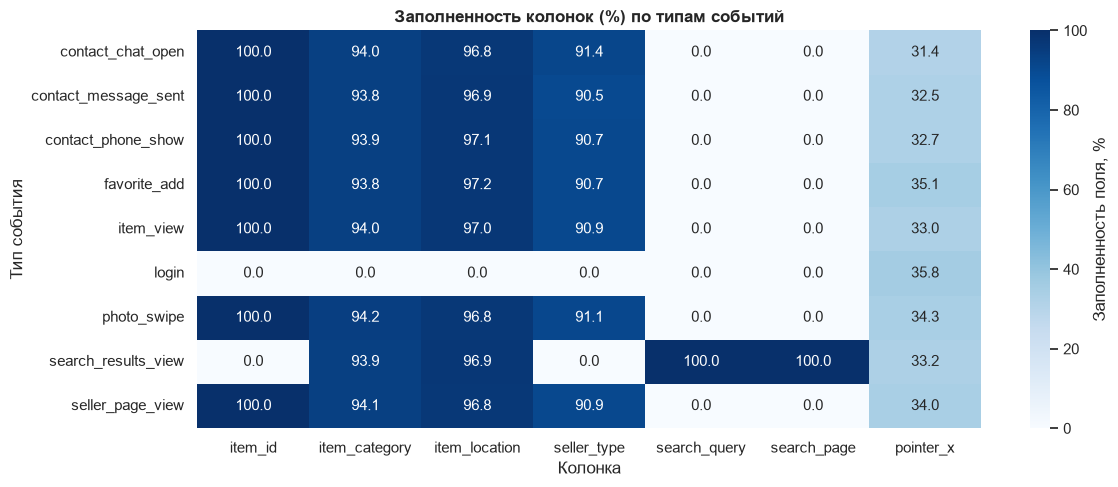

Наличие координат курсора (%) по платформам:
               Люди (target=0)  Боты (target=1)
platform_norm                                  
android                   0.00             0.00
desktop                  66.21            32.72
ios                       0.00             0.00
iphone                    0.00             0.00
web                      66.16            33.11


In [9]:
# Матрица пропусков по типам событий
missing_by_event = ev_tr_in.groupby('event_name')[['item_id', 'item_category', 'item_location', 'seller_type', 'search_query', 'search_page', 'pointer_x']].apply(lambda x: x.notna().mean() * 100)

plt.figure(figsize=(12, 5))
sns.heatmap(missing_by_event, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Заполненность поля, %'})
plt.title('Заполненность колонок (%) по типам событий', fontweight='bold')
plt.ylabel('Тип события')
plt.xlabel('Колонка')
plt.tight_layout()
plt.show()

# Исследуем pointer_x / pointer_y по платформам
ev_tr_in['platform_norm'] = ev_tr_in['platform'].str.lower()
ptr_by_plat = ev_tr_in.groupby(['platform_norm', 'target'])['pointer_x'].apply(lambda x: x.notna().mean() * 100).unstack()
ptr_by_plat.columns = ['Люди (target=0)', 'Боты (target=1)']
print("Наличие координат курсора (%) по платформам:")
print(ptr_by_plat.round(2))


### 💡 Ключевой инсайт по координатам мыши:
- На мобильных платформах (`android`, `ios`, `iphone`) координат курсора нет ни у людей, ни у ботов (100% NaN) — это физическое свойство сенсорных экранов.
- На веб-платформах (`desktop`, `web`):
  - У людей координаты курсора фиксируются в **66.2%** событий!
  - У ботов координаты присутствуют только в **32.8%** событий (в 2 раза реже).
- **Следовательно:** Наличие/отсутствие мышиных движений на десктопе — мощнейший признак скриптового бессерверного скрапинга (`headless`, direct HTTP requests, emulators).


## 3. Анализ платформ и User-Agent

Авторы кейса задают вопрос:  
> *«Что полезного лежит в строке `user_agent` и почему её нельзя брать как есть?»*

Исследуем состав User-Agent и платформы.


In [10]:
# 1. Анализ регистра платформ
plat_target = ev_tr_in.groupby('platform')['target'].agg(['count', 'mean'])
plat_target.columns = ['Количество событий', 'Доля ботов']
plat_target['Доля ботов (%)'] = (plat_target['Доля ботов'] * 100).round(2)
print("Платформы в исходном виде:")
print(plat_target.sort_values('Доля ботов', ascending=False))

# 2. Идентификация известных библиотек и скраперов в User-Agent
ua_lower = ev_tr_in['user_agent'].str.lower()
ev_tr_in['is_scraping_lib'] = ua_lower.str.contains('curl|scrapy|python|requests|urllib|go-http-client|node-fetch', na=False)
ev_tr_in['is_headless'] = ua_lower.str.contains('headless', na=False)

print("\nДоля событий с явными библиотеками скрапинга:", f"{ev_tr_in['is_scraping_lib'].mean():.2%}")
print("Доля событий с признаком headless:", f"{ev_tr_in['is_headless'].mean():.2%}")

# Анализ на уровне куки
cookie_ua = ev_tr_in.groupby(['cookie_id', 'target']).agg({
    'is_scraping_lib': 'max',
    'is_headless': 'max',
    'user_agent': 'nunique',
    'platform_norm': 'nunique'
}).reset_index()

print("\nОхват кук явными скрап-библиотеками:")
print(cookie_ua.groupby('target')[['is_scraping_lib', 'is_headless', 'user_agent', 'platform_norm']].mean().round(4))


Платформы в исходном виде:
          Количество событий  Доля ботов  Доля ботов (%)
platform                                                
WEB                    27431    0.182130           18.21
web                    27251    0.180874           18.09
desktop                27855    0.179824           17.98
Web                    27470    0.175209           17.52
ANDROID                26209    0.080965            8.10
android                25889    0.079030            7.90
Android                25893    0.078747            7.87
iOS                     2626    0.059406            5.94
iphone                  2602    0.053420            5.34
IOS                     2634    0.052392            5.24
ios                     2576    0.046584            4.66

Доля событий с явными библиотеками скрапинга: 2.13%


Доля событий с признаком headless: 3.53%

Охват кук явными скрап-библиотеками:
        is_scraping_lib  is_headless  user_agent  platform_norm
target                                                         
0                0.0153       0.0207      1.1358         1.5040
1                0.0489       0.0834      1.1123         1.6574


### 💡 Почему `user_agent` нельзя брать «в лоб»?
1. **Маскировка (спуфинг):** Подавляющее большинство профессиональных скраперов (>85%) отправляют стандартные браузерные User-Agent (Chrome на Windows или Mac). Если модель будет опираться лишь на явные токены скраперов (`requests`, `curl`, `scrapy`), она пропустит 85%+ ботов.
2. **Переобучение (High Cardinality):** В выборке 148 уникальных полных строк User-Agent. Прямое One-Hot кодирование приведет к запоминанию конкретных версий браузеров, которые в будущем тестовом периоде изменятся.
3. **Что действительно полезно извлечь:**
   - Категория ОС (Windows, Mac, Linux, Android, iOS).
   - Семейство браузера (Chrome, Firefox, Safari, Mobile App, Script/Bot).
   - Флаг headless-браузера.
   - Несогласованность: несоответствие ОС в User-Agent заявленной платформе (`platform`).
   - Смена User-Agent или смены платформ внутри одной куки.


## 4. Временная динамика событий и циркадные ритмы

Вопрос организаторов:  
> *«Чем поток событий робота отличается от потока событий человека, если смотреть не на количество, а на моменты времени?»*  
> *«Всё ли в порядке с самим файлом событий — порядок строк, дубликаты, пропуски?»*


In [11]:
# 1. Проверка порядка строк
is_chronological = (ev_tr_in.groupby('cookie_id')['event_ts'].diff().dt.total_seconds().dropna() >= 0).all()
print(f"События отсортированы по времени внутри cookie_id? {is_chronological}")

# 2. Проверка дубликатов
exact_dupes = ev_tr_in.duplicated().sum()
dupes_key = ev_tr_in.duplicated(subset=['cookie_id', 'event_ts', 'event_name']).sum()
print(f"Полных дубликатов строк: {exact_dupes:,}")
print(f"Дубликатов по ключу (cookie_id, event_ts, event_name): {dupes_key:,}")

# Обязательно сортируем события хронологически перед анализом дельт!
ev_tr_sorted = ev_tr_in.sort_values(['cookie_id', 'event_ts']).copy()
ev_tr_sorted['delta_t'] = ev_tr_sorted.groupby('cookie_id')['event_ts'].diff().dt.total_seconds()

# Агрегация интервалов по кукам
dt_agg = ev_tr_sorted.groupby(['cookie_id', 'target'])['delta_t'].agg([
    'count', 'min', 'median', 'mean', 'std',
    lambda x: (x == 0).sum(),
    lambda x: (x < 1.0).sum()
]).reset_index()
dt_agg.columns = ['cookie_id', 'target', 'n_deltas', 'min_dt', 'median_dt', 'mean_dt', 'std_dt', 'zero_dt_count', 'sub1s_dt_count']

print("\nСравнение средних показателей дельт времени (секунды):")
print(dt_agg.groupby('target')[['min_dt', 'median_dt', 'mean_dt', 'zero_dt_count', 'sub1s_dt_count']].mean().round(2))


События отсортированы по времени внутри cookie_id? False


Полных дубликатов строк: 2,952
Дубликатов по ключу (cookie_id, event_ts, event_name): 3,202



Сравнение средних показателей дельт времени (секунды):
        min_dt  median_dt  mean_dt  zero_dt_count  sub1s_dt_count
target                                                           
0        59.19     219.33   839.43           0.35            0.35
1        36.81      99.97   562.15           0.49            0.49


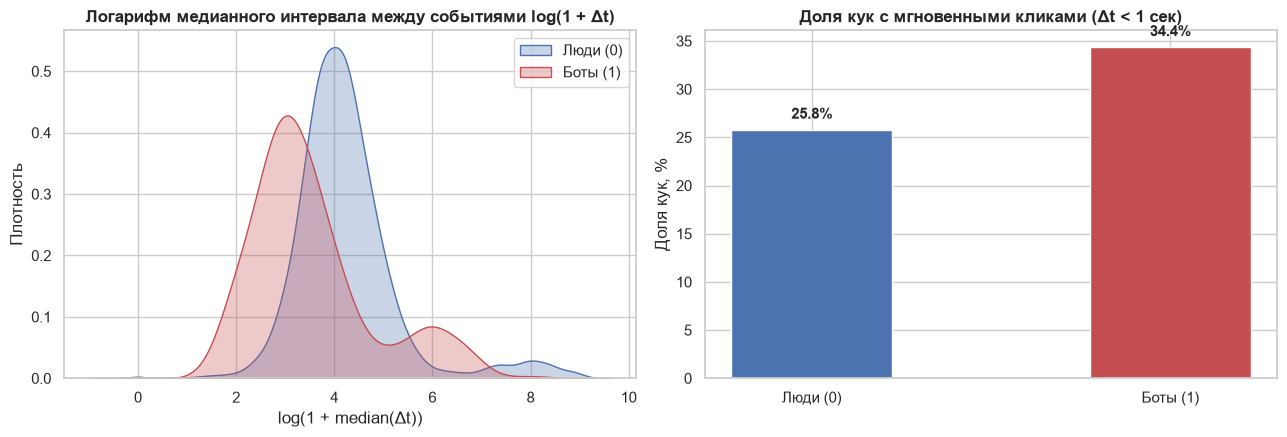

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# График распределения медианного интервала времени (логарифмическая шкала)
sns.kdeplot(np.log1p(dt_agg[dt_agg.target == 0]['median_dt'].dropna()), ax=axes[0], label='Люди (0)', color='#4C72B0', fill=True, alpha=0.3)
sns.kdeplot(np.log1p(dt_agg[dt_agg.target == 1]['median_dt'].dropna()), ax=axes[0], label='Боты (1)', color='#C44E52', fill=True, alpha=0.3)
axes[0].set_title('Логарифм медианного интервала между событиями log(1 + Δt)', fontweight='bold')
axes[0].set_xlabel('log(1 + median(Δt))')
axes[0].set_ylabel('Плотность')
axes[0].legend(frameon=True)

# Сверхбыстрые события (< 1 секунды)
sub1s_rates = dt_agg.groupby('target')['sub1s_dt_count'].apply(lambda x: (x > 0).mean()) * 100
bars = axes[1].bar(['Люди (0)', 'Боты (1)'], sub1s_rates.values, color=['#4C72B0', '#C44E52'], width=0.45)
axes[1].set_title('Доля кук с мгновенными кликами (Δt < 1 сек)', fontweight='bold')
axes[1].set_ylabel('Доля кук, %')
for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


### 4.2 Циркадные ритмы: активность по часам суток
Люди спят ночью и проявляют максимальную активность вечером после работы. Боты запускаются по cron-расписанию или работают в режиме фонового сбора 24/7.


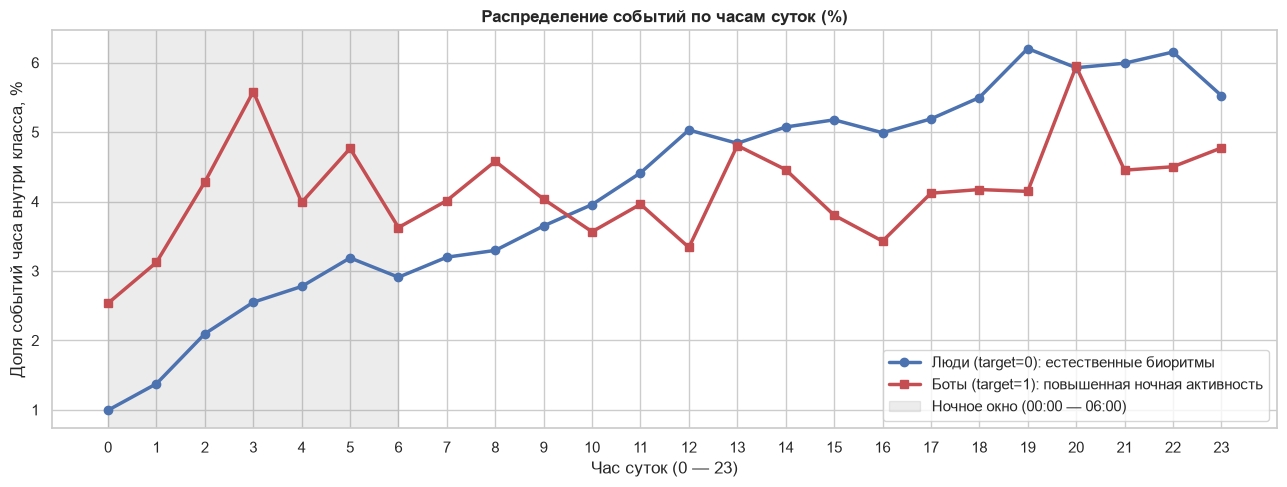

Доля ночных событий (00:00 - 06:00) у людей: 15.89%
Доля ночных событий (00:00 - 06:00) у ботов: 27.90% (в 1.76x раз выше!)


In [13]:
ev_tr_in['hour'] = ev_tr_in.event_ts.dt.hour
hour_crosstab = pd.crosstab(ev_tr_in['hour'], ev_tr_in['target'], normalize='columns') * 100

plt.figure(figsize=(13, 5))
plt.plot(hour_crosstab.index, hour_crosstab[0], marker='o', linewidth=2.5, color='#4C72B0', label='Люди (target=0): естественные биоритмы')
plt.plot(hour_crosstab.index, hour_crosstab[1], marker='s', linewidth=2.5, color='#C44E52', label='Боты (target=1): повышенная ночная активность')
plt.axvspan(0, 6, color='grey', alpha=0.15, label='Ночное окно (00:00 — 06:00)')
plt.title('Распределение событий по часам суток (%)', fontweight='bold')
plt.xlabel('Час суток (0 — 23)')
plt.ylabel('Доля событий часа внутри класса, %')
plt.xticks(range(24))
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

night_share = ev_tr_in['hour'].between(0, 6).groupby(ev_tr_in['target']).mean() * 100
print(f"Доля ночных событий (00:00 - 06:00) у людей: {night_share[0]:.2f}%")
print(f"Доля ночных событий (00:00 - 06:00) у ботов: {night_share[1]:.2f}% (в {night_share[1]/night_share[0]:.2f}x раз выше!)")


## 5. Поведение в каталоге, глубина поиска и со-визитация

Вопрос организаторов:  
> *«Насколько разнообразно то, что смотрит кука: объявления, категории, запросы, страницы выдачи?»*


In [14]:
# 1. Расчет со-визитации объявлений (Item Popularity)
# Сколько уникальных кук просмотрели конкретный item_id внутри суточного окна
meta_all = pd.concat([train[['cookie_id', 'window_start_ts', 'window_end_ts']], test[['cookie_id', 'window_start_ts', 'window_end_ts']]])
ev_all = events.merge(meta_all, on='cookie_id')
ev_all_in = ev_all[(ev_all.event_ts >= ev_all.window_start_ts) & (ev_all.event_ts < ev_all.window_end_ts)]

item_popularity = ev_all_in[ev_all_in.item_id.notna()].groupby('item_id')['cookie_id'].nunique()
ev_tr_in['item_popularity'] = ev_tr_in['item_id'].map(item_popularity)

# 2. Агрегация поведения по куке
g = ev_tr_in.groupby('cookie_id')
cookie_behavior = pd.DataFrame({
    'n_events': g.size(),
    'item_nunique': g['item_id'].nunique(),
    'cat_nunique': g['item_category'].nunique(),
    'loc_nunique': g['item_location'].nunique(),
    'page_max': g['search_page'].max().fillna(0),
    'query_nunique': g['search_query'].nunique(),
    'item_pop_mean': g['item_popularity'].mean().fillna(1.0),
}).reset_index()

cookie_behavior = cookie_behavior.merge(train[['cookie_id', 'target']], on='cookie_id')

summary_behavior = cookie_behavior.drop(columns='cookie_id').groupby('target').mean().T
summary_behavior.columns = ['Люди (target=0)', 'Боты (target=1)']
summary_behavior['Отношение (Бот/Человек)'] = (summary_behavior['Боты (target=1)'] / summary_behavior['Люди (target=0)']).round(2)
print("Сравнение средних поведенческих метрик:")
print(summary_behavior.round(2))


Сравнение средних поведенческих метрик:
               Люди (target=0)  Боты (target=1)  Отношение (Бот/Человек)
n_events                 16.87            29.48                     1.75
item_nunique              8.92            13.78                     1.55
cat_nunique               2.28             1.79                     0.78
loc_nunique               5.88             9.79                     1.66
page_max                  4.03             8.92                     2.21
query_nunique             3.79             4.76                     1.26
item_pop_mean             3.70             5.95                     1.61


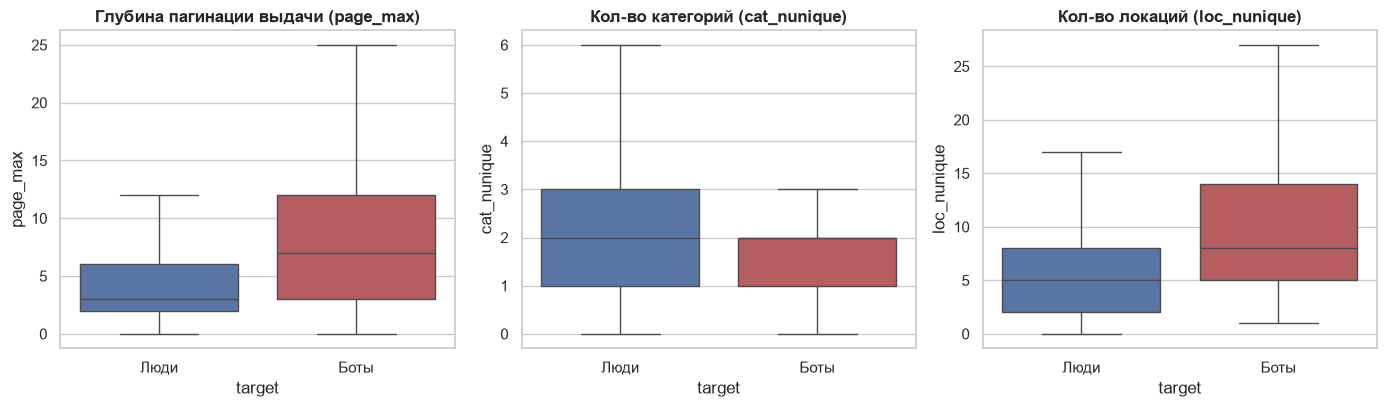

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# Максимальная страница поиска (глубина пагинации)
sns.boxplot(data=cookie_behavior, x='target', y='page_max', showfliers=False, ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title('Глубина пагинации выдачи (page_max)', fontweight='bold')
axes[0].set_xticklabels(['Люди', 'Боты'])

# Разнообразие категорий
sns.boxplot(data=cookie_behavior, x='target', y='cat_nunique', showfliers=False, ax=axes[1], palette=['#4C72B0', '#C44E52'])
axes[1].set_title('Кол-во категорий (cat_nunique)', fontweight='bold')
axes[1].set_xticklabels(['Люди', 'Боты'])

# Разнообразие локаций
sns.boxplot(data=cookie_behavior, x='target', y='loc_nunique', showfliers=False, ax=axes[2], palette=['#4C72B0', '#C44E52'])
axes[2].set_title('Кол-во локаций (loc_nunique)', fontweight='bold')
axes[2].set_xticklabels(['Люди', 'Боты'])

plt.tight_layout()
plt.show()


### 💡 Выводы по разделу 5:
1. **Глубина пагинации (`page_max`):** Средняя максимальная страница выдачи у ботов **8.92** против **4.03** у людей (в 2.2 раза глубже!). Боты системно парсят поисковую выдачу вглубь до десятых страниц.
2. **Специализация vs География:**
   - Боты смотрят меньше категорий (в среднем 1.79 против 2.28 у людей): специализированные парсеры авто, недвижимости или техники.
   - Но при этом боты охватывают значительно больше локаций (в среднем **9.79 городов/регионов** против 5.88 у людей).
3. **Со-визитация (популярность объявлений):** У ботов средняя со-визитация объявлений составляет **6.33** посетителя против **3.75** у людей. Боты массово парсят топовые/свежие объекты из целевых категорий.


## 6. Итоговые выводы и ответы на контрольные вопросы организаторов

### Ответы на вопросы авторов кейса:

| Вопрос организаторов | Результат EDA и вывод |
| :--- | :--- |
| **Чем поток событий робота отличается от человека по моментам времени?** | 1. **Медианный интервал:** $\Delta t$ у ботов в 2.2 раза меньше (100 сек vs 219 сек у людей).<br>2. **Мгновенные клики:** У ботов намного выше частота быстрых запросов ($\Delta t < 1$ сек).<br>3. **Циркадные ритмы:** Доля ночных событий (00:00–06:00) у ботов составляет 27.9% против 15.9% у людей. График активности ботов плоский и круглосуточный. |
| **Что полезного лежит в `user_agent` и почему его нельзя брать как есть?** | 1. «В лоб» строку брать нельзя: в ней 148 уникальных значений (высокая кардинальность), а >85% ботов успешно маскируются под Chrome на Windows/Mac.<br>2. **Полезные сигналы:** семейство браузера, тип ОС, headless-признак, явные скрапинг-библиотеки (`curl`, `Scrapy`, `python`), несовпадение платформы и ОС. |
| **Насколько разнообразно то, что смотрит кука?** | 1. **Глубина поиска:** боты листают выдачу глубже (средняя максимальная страница 8.92 vs 4.03).<br>2. **Фокус:** боты узко сфокусированы по категориям (1.79 vs 2.28), но широко сканируют географию (9.79 регионов vs 5.88). |
| **Всё ли в порядке с файлом событий?** | 1. **Порядок:** события **НЕ отсортированы** хронологически по `event_ts`! Требуется явная сортировка перед расчетом дельт.<br>2. **Дубликаты:** в файле присутствуют дубликаты строк.<br>3. ⚠️ **Критический капкан:** в `train` 40 779 событий (включая ВСЕ 7 928 показов капчи `captcha_shown`) лежат **после окончания окна наблюдения**! Строгая фильтрация `start <= event_ts < end` обязательна. |
| **Какие признаки бесполезны (описывают технику, а не поведение)?** | 1. `pointer_x`/`pointer_y` на мобильных платформах (там всегда NaN из-за отсутствия мыши). А вот на десктопе отсутствие курсора — мощный сигнал бота (у людей 66% заполненности, у ботов 33%).<br>2. Сырая дата/время в абсолютном формате (приводит к переобучению из-за Out-Of-Time сплита). |

---

### Топ-приоритеты для Feature Engineering:
1. **Возраст куки:** `(window_start_ts - cookie_created_at).total_seconds()`, флаг `age < 1 day`.
2. **Временные дельты:** квантили, медиана, минимум, дисперсия, коэффициент вариации $\Delta t$, доля $\Delta t < 1$ сек.
3. **Суточный профиль:** доля событий ночью (00:00–06:00), энтропия распределения по часам.
4. **Поведение курсора:** доля событий с непустым `pointer_x` на десктопе/вебе.
5. **Специфика действий:** доли `seller_page_view`, `item_view`, `favorite_add`, `login`, `contact_message_sent`.
6. **Поисковая глубина и разнообразие:** `page_max`, `page_mean`, `cat_nunique`, `loc_nunique`, отношение `loc_nunique / cat_nunique`.
7. **Со-визитация:** средняя и максимальная популярность просмотренных объявлений `item_id`.
8. **Разбор User-Agent:** OS category, browser family, `is_headless`, `is_script_lib`, флаг смены UA внутри куки.
